## Imports

In [148]:
TEST_SIZE = 0.2

BATCH_SIZE = 64
EPOCHS = 100
LR = 1e-3

CKPT_BASE = 'checkpoints' 

In [134]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from tqdm import trange
from collections import defaultdict
import math
import random
import itertools
import sentencepiece as spm
import tempfile
import re
from typing import List, Tuple, Dict
import matplotlib.pyplot as plt
import os
import subprocess
from pathlib import Path


import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torch.amp import autocast, GradScaler

In [135]:
df_full = pd.read_csv('../data/full_data_non_null.csv')
df_full["timestamp"] = pd.to_datetime(df_full["timestamp"])
df_full = df_full[df_full['timestamp'] >= '2016-01-01'] # Filter out data before 2016-01-01

## Preprocessing

### From exploration

In [136]:
df_full = df_full.drop(columns=["hour", "day", "month", "year"]) # Are dupes of timestamp
df_full = df_full.drop(columns=["location"]) # Are dupes of location_id
df_full = df_full.drop(columns=["cluster_size"]) # Only contain 1 unique value, so not useful for modeling

# Temporary drops
df_full = df_full.drop(columns=["latitude", "longitude"]) # Geospatial info, but may be too high-cardinality and low data count for now

### Main Preprocess

In [137]:
# Lable encode for location_id
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_full['location_id'] = le.fit_transform(df_full['location_id'])

In [138]:
# Compute step index
# Get minimum timestamp
t0 = df_full['timestamp'].min()

# Compute step (in hours)
df_full['step'] = (df_full['timestamp'] - t0) / pd.Timedelta(hours=1)

# Optional: make it integer (since your data is hourly)
df_full['step'] = df_full['step'].astype(int)
df_full.drop(columns=["timestamp"], inplace=True) # Drop original timestamp since we have step now

### Train-test Split

In [139]:
# Ensure proper order per location
df = df_full.sort_values(['location_id', 'step'])

train_list = []
test_list = []

for loc, group in df.groupby('location_id'):
    split_idx = int(len(group) * (1 - TEST_SIZE))
    
    train_list.append(group.iloc[:split_idx])
    test_list.append(group.iloc[split_idx:])

df_train = pd.concat(train_list).reset_index(drop=True)
df_test  = pd.concat(test_list).reset_index(drop=True)

print(f"Train shape: {df_train.shape}, Test shape: {df_test.shape}")
print(f"Final Ratios - Train: {len(df_train) / len(df_full):.2f}, Test: {len(df_test) / len(df_full):.2f}")

Train shape: (210530, 34), Test shape: (52635, 34)
Final Ratios - Train: 0.80, Test: 0.20


## Training Utilities

### DF to Tensor

In [140]:
import numpy as np

def df_to_sequences(df):
    df = df.copy()
    df = df.sort_values(['location_id', 'step'])
    
    # Identify feature columns
    feature_cols = [c for c in df.columns if c not in ['location_id', 'step', 'y']]
    
    sequences = []
    
    for loc_id, group in df.groupby('location_id'):
        group = group.sort_values('step')
        
        X = group[feature_cols].values.astype(float)  # (seq_len, n_feat)
        y = group['y'].values.astype(float)           # (seq_len,)
        
        sequences.append({
            'location_id': int(loc_id),
            'X': X,
            'y': y
        })
    
    return sequences, feature_cols

### Dataset and DataLoader

In [141]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def make_data_loaders(sequences, batch_size=32):
    res = []
    for seq in sequences:
        X = torch.tensor(seq['X'], dtype=torch.float32)  # (seq_len, n_feat)
        y = torch.tensor(seq['y'], dtype=torch.float32)  # (seq_len,)
        
        dataset = TimeSeriesDataset(X, y)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
        
        res.append({
            'location_id': torch.tensor(seq['location_id'], dtype=torch.int64),
            'loader': loader
        })
        
    return res

### Evaluator

In [142]:
def r2_score(y_true, y_pred):
    y_true = np.ravel(y_true)
    y_pred = np.ravel(y_pred)

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    return 1 - (ss_res / ss_tot)

def evaluate(data_loaders, model, device):
    model.eval()
    all_preds = []
    all_trues = []
    
    with torch.no_grad():
        for item in data_loaders:
            location_id = item['location_id'].to(device)
            loader = item['loader']
            
            for X_batch, y_batch in loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                
                preds, _ = model(X_batch, location_id)  # (batch_size, seq_len)
                
                all_preds.append(preds.cpu().numpy())
                all_trues.append(y_batch.cpu().numpy())
    
    all_preds = np.concatenate(all_preds)
    all_trues = np.concatenate(all_trues)
    
    r2 = r2_score(all_trues, all_preds)
    return r2

### Training Function

In [143]:
def train_gru(model,
                      train_loaders, 
                      test_loaders,
                      batch_size=32,
                      epochs=100,
                      lr=1e-3,
                      device='cuda'):
    """
    Time series trainer that handles location_id capabilities and uses GRU model architecture
    """
    
    
    
    # Optimizer and criterion
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    model.to(device)
    
    pbar = trange(epochs, desc="Training")
    progression = []
    
    for epoch in pbar:
        model.train()
        train_losses = []
        
        for train_seq in train_loaders:
            location_id = train_seq['location_id']
            location_id = location_id.to(device)
            for X_batch, y_batch in train_seq['loader']:
                
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                
                optimizer.zero_grad()
                y_pred, _ = model(X_batch, location_id)  # (batch_size, seq_len)
                
                loss = criterion(y_pred, y_batch)
                loss.backward()
                optimizer.step()
                optimizer.zero_grad()
                
                train_losses.append(loss.item())
        
        avg_train_loss = np.mean(train_losses)
        
        # Evaluation
        model.eval()
        test_losses = []
        
        with torch.no_grad():
            for test_seq in test_loaders:
                location_id = test_seq['location_id']
                location_id = location_id.to(device)
                for X_batch, y_batch in test_seq['loader']:
                    X_batch = X_batch.to(device)
                    y_batch = y_batch.to(device)
                    
                    y_pred, _ = model(X_batch, location_id)
                    loss = criterion(y_pred, y_batch)
                    test_losses.append(loss.item())
                    
        train_r2 = evaluate(train_loaders, model, device=device)
        test_r2 = evaluate(test_loaders, model, device=device)
                
        pbar.set_postfix({
            'train_loss': avg_train_loss,
            'test_loss': np.mean(test_losses),
            'train_r2': train_r2,
            'test_r2': test_r2
        })
        
        progression.append({
            'epoch': epoch,
            'train_loss': avg_train_loss,
            'test_loss': np.mean(test_losses),
            'train_r2': train_r2,
            'test_r2': test_r2
        })
        
    return progression

## Model

### MoE : PerFeatureGRU + EmbedRouter

In [144]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class MoEGRU(nn.Module):
    def __init__(
        self,
        n_feat,
        n_locations,
        d_model=64,
        n_experts=8,
        emb_dim=16,
        gru_layers=1,
    ):
        super().__init__()

        self.d_model = d_model
        self.n_experts = n_experts
        self.gru_layers = gru_layers

        # GRU (core temporal model)
        self.gru = nn.GRU(
            input_size=n_feat,
            hidden_size=d_model,
            num_layers=gru_layers,
            batch_first=True,
        )

        # location embedding
        self.loc_emb = nn.Embedding(n_locations, emb_dim)

        # router (location → expert weights)
        self.router = nn.Sequential(
            nn.Linear(emb_dim, d_model),
            nn.ReLU(),
            nn.Linear(d_model, n_experts)
        )

        # experts (operate on h_t)
        self.experts = nn.ModuleList([
            nn.Sequential(
                nn.Linear(d_model, d_model),
                nn.ReLU(),
                nn.Linear(d_model, 1)
            )
            for _ in range(n_experts)
        ])

    def forward(self, X, location_id, h=None):
        """
        X: (B, n_feat)
        location_id: (B,)
        h: (layers, B, d_model)

        returns:
            y: (B, 1)
            h_new: (layers, B, d_model)
        """

        B = X.size(0)

        # GRU step
        X_in = X.unsqueeze(1)                 # (B, 1, n_feat)
        _, h_new = self.gru(X_in, h)          # (layers, B, d_model)
        h_t = h_new[-1]                       # (B, d_model)

        # experts forward
        expert_outputs = torch.stack(
            [exp(h_t) for exp in self.experts],
            dim=-1
        )                                     # (B, 1, n_experts)

        # routing (ONLY from location)
        loc_vec = self.loc_emb(location_id)    # (B, emb_dim)
        gate_logits = self.router(loc_vec)     # (B, n_experts)
        gate_weights = F.softmax(gate_logits, dim=-1)

        # merge
        y = torch.sum(
            expert_outputs.squeeze(1) * gate_weights,
            dim=-1,
            keepdim=True
        )                                      # (B, 1)

        return y, h_new

## Training and Plot

### Model Definition

In [145]:
# Convert DataFrames to sequences
train_sequences, feature_cols = df_to_sequences(df_train)
test_sequences, _ = df_to_sequences(df_test)

# Create DataLoaders
train_loaders = make_data_loaders(train_sequences, BATCH_SIZE)
test_loaders = make_data_loaders(test_sequences, BATCH_SIZE)


model = MoEGRU(
    n_feat=len(feature_cols),
    n_locations=df['location_id'].nunique(),
    d_model=128,
    n_experts=16, # 16 Locations from EDA
    emb_dim=16,
    gru_layers=1,
)

print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")

MoEGRU(
  (gru): GRU(31, 128, batch_first=True)
  (loc_emb): Embedding(15, 16)
  (router): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=16, bias=True)
  )
  (experts): ModuleList(
    (0-15): 16 x Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=1, bias=True)
    )
  )
)
Total parameters: 332560


### Train

In [146]:
progression = train_gru(
    model,
    train_loaders,
    test_loaders,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    lr=LR,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

Training:   0%|          | 0/100 [00:00<?, ?it/s]c:\Users\alief\anaconda3\envs\kaggle\Lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([64])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\alief\anaconda3\envs\kaggle\Lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([19])) that is different to the input size (torch.Size([19, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\alief\anaconda3\envs\kaggle\Lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([20])) that is different to the input size (torch.Size([20, 1])). This will likely lead to incorrect 

### Plot

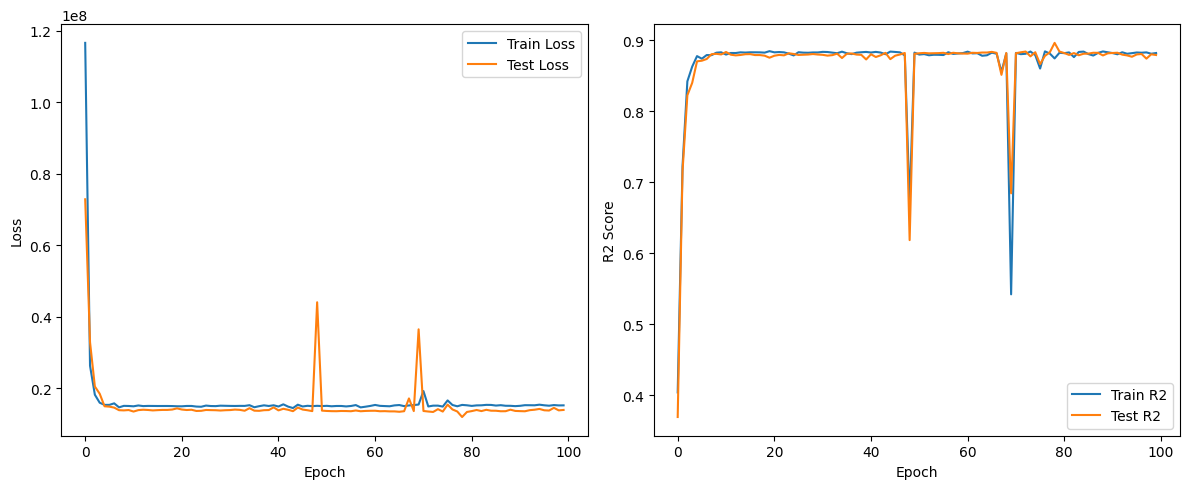

In [147]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot([p['epoch'] for p in progression], [p['train_loss'] for p in progression], label='Train Loss')
ax1.plot([p['epoch'] for p in progression], [p['test_loss'] for p in progression], label='Test Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot([p['epoch'] for p in progression], [p['train_r2'] for p in progression], label='Train R2')
ax2.plot([p['epoch'] for p in progression], [p['test_r2'] for p in progression], label='Test R2')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('R2 Score')
ax2.legend()

plt.tight_layout()
plt.show()

### Save to path

In [150]:
os.makedirs(CKPT_BASE, exist_ok=True)
torch.save(model.state_dict(), f'{CKPT_BASE}/gru_moe_model.pth')

### Plot every prediction

In [159]:
reconstruct_result = []

device = 'cuda' if torch.cuda.is_available() else 'cpu'
for train_item, test_item in zip(train_loaders, test_loaders):
    location_id = train_item['location_id']
    
    # Get all train predictions and trues for this location
    train_preds = []
    train_trues = []
    for X_batch, y_batch in train_item['loader']:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        h_last = None
        
        with torch.no_grad():
            preds, h_last = model(X_batch, 
                                  h_last,
                                  location_id.to(device)) if h_last is not None else model(X_batch, location_id.to(device))
        
        train_preds.append(preds.cpu().numpy())
        train_trues.append(y_batch.cpu().numpy())
    
    train_preds = np.concatenate(train_preds)
    train_trues = np.concatenate(train_trues)
    
    # Get all test predictions and trues for this location
    test_preds = []
    test_trues = []
    for X_batch, y_batch in test_item['loader']:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        h_last = None
        
        with torch.no_grad():
            preds, h_last = model(X_batch, 
                              h_last,
                              location_id.to(device)) if h_last is not None else model(X_batch, location_id.to(device))
        
        test_preds.append(preds.cpu().numpy())
        test_trues.append(y_batch.cpu().numpy())
    
    test_preds = np.concatenate(test_preds)
    test_trues = np.concatenate(test_trues)
    
    reconstruct_result.append({
        'location_id': location_id,
        'preds': np.concatenate([train_preds, test_preds]),
        'trues': np.concatenate([train_trues, test_trues]),
    })
    

[[16238.757]
 [16238.757]
 [16238.757]
 [16238.757]
 [16238.757]
 [16238.757]
 [16238.757]
 [16238.757]
 [16238.757]
 [16238.757]]
[[22266.793]
 [22266.793]
 [22266.793]
 [22266.793]
 [22266.793]
 [22266.793]
 [22266.793]
 [22266.793]
 [22266.793]
 [22266.793]]
[[22288.268]
 [22288.268]
 [22288.268]
 [22288.268]
 [22288.268]
 [22288.268]
 [22288.268]
 [22288.268]
 [22288.268]
 [22288.268]]
[[32978.04]
 [32978.04]
 [32978.04]
 [32978.04]
 [32978.04]
 [32978.04]
 [32978.04]
 [32978.04]
 [32978.04]
 [32978.04]]
[[10242.371]
 [10242.371]
 [10242.371]
 [10242.371]
 [10242.371]
 [10242.371]
 [10242.371]
 [10242.371]
 [10242.371]
 [10242.371]]
[[32978.055]
 [32978.055]
 [32978.055]
 [32978.055]
 [32978.055]
 [32978.055]
 [32978.055]
 [32978.055]
 [32978.055]
 [32978.055]]
[[7814.5654]
 [7814.5654]
 [7814.5654]
 [7814.5654]
 [7814.5654]
 [7814.5654]
 [7814.5654]
 [7814.5654]
 [7814.5654]
 [7814.5654]]
[[14260.731]
 [14260.731]
 [14260.731]
 [14260.731]
 [14260.731]
 [14260.731]
 [14260.731]
 [

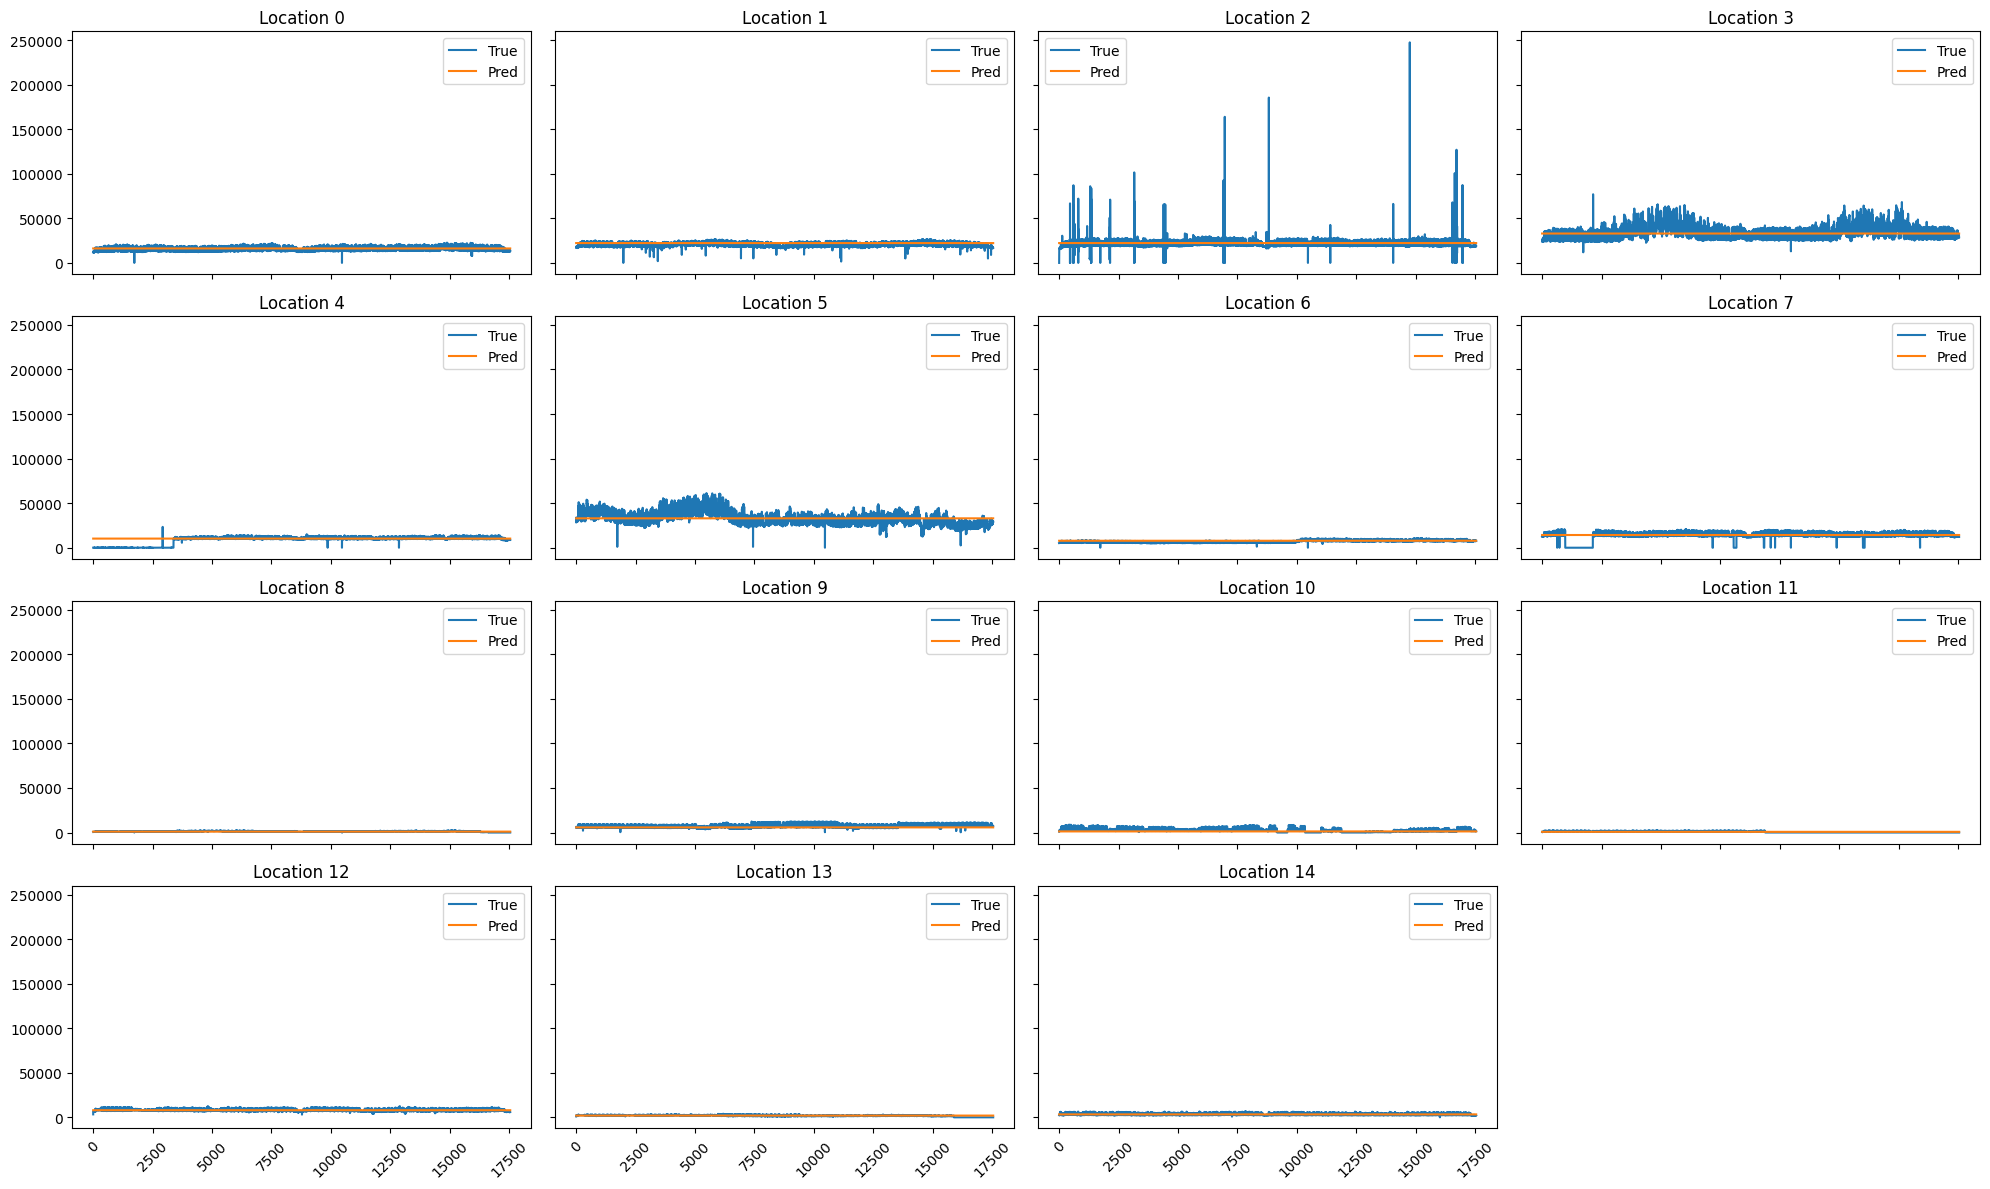

In [160]:
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(20, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, res in enumerate(reconstruct_result):
    loc = res['location_id']
    ax = axes[i]
    
    ax.plot(res['trues'], label='True')
    ax.plot(res['preds'], label='Pred')
    print(res['preds'][:10])
    ax.set_title(f'Location {loc}')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    

# Hide unused subplots if <16 locations
for j in range(len(reconstruct_result), 16):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()